In [2]:
#EXCERCISE 1 - Bernstein-Vaziriani algorithm

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.primitives import StatevectorSampler
from qiskit_ibm_runtime import SamplerV2
from qiskit_ibm_runtime.fake_provider import FakeKyiv


# K = 0 1 0 0 1 0 1 1

def bv_query(s):
    # Create a quantum circuit implementing a query gate for the
    # Bernstein-Vazirani problem.

    qc = QuantumCircuit(len(s) + 1)
    for index, bit in enumerate(reversed(s)):
        if bit == "1":
            qc.cx(index, len(s))
    return qc


# display(bv_query("01001011").draw(output="mpl")) #ASCII for K like Kacper


def compile_circuit(function: QuantumCircuit):
    # Compiles a circuit for use in the Deutsch-Jozsa (or Bernstein-Vazirani) algorithm.

    n = function.num_qubits - 1
    qc = QuantumCircuit(n + 1, n)
    qc.x(n)
    qc.h(range(n + 1))
    qc.compose(function, inplace=True)
    qc.h(range(n))
    qc.measure(range(n), range(n))
    return qc


def bv_algorithm(function: QuantumCircuit):
    qc = compile_circuit(function)
    result = AerSimulator().run(qc, shots=1, memory=True).result()
    return result.get_memory()[0]


oracle = bv_query("01001011")
qc = compile_circuit(oracle)
display(bv_algorithm(oracle))

sampler = StatevectorSampler()
result = sampler.run([qc], shots=1024).result()
print(result[0].data)
print(result[0].data.keys())
counts = result[0].data.c.get_counts()

print("Noiseless:", counts)

backend = FakeKyiv()
qc_noisy = transpile(qc, backend)

sampler_noisy = SamplerV2(backend)
result_noisy = sampler_noisy.run([qc_noisy], shots=1024).result()
counts_noisy = result_noisy[0].data.c.get_counts()

print("Noisy:", counts_noisy)



'01001011'

DataBin(c=BitArray(<shape=(), num_shots=1024, num_bits=8>))
dict_keys(['c'])
Noiseless: {'01001011': 1024}
Noisy: {'01001011': 935, '01001001': 15, '00001001': 7, '00001011': 17, '01101011': 5, '00000001': 13, '01001010': 8, '01000011': 20, '00000011': 2, '00000000': 1, '01001111': 1}


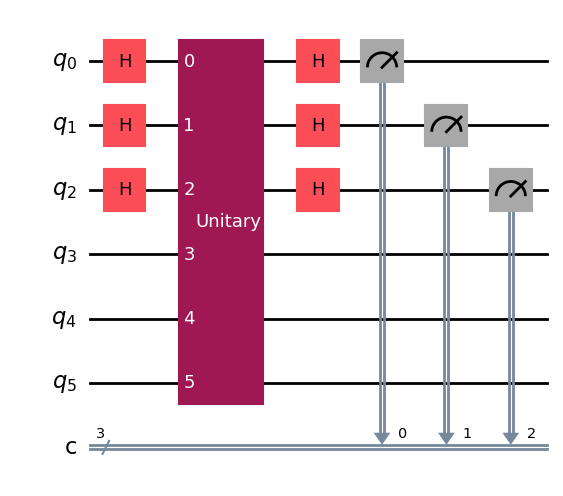

counts:
{'100': 259, '011': 284, '111': 245, '000': 236}


In [4]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.primitives import StatevectorSampler
from qiskit_ibm_runtime import SamplerV2
from qiskit_ibm_runtime.fake_provider import FakeKyiv


#In this cell we implement simon algorithm and make the measurements
def simon_function(s: str):
    n = len(s)
    qc = QuantumCircuit(2 * n)

    pi = np.random.permutation(2**n)
    hidden = int(s, 2)

    query_gate = np.zeros((4**n, 4**n))

    for x in range(2**n):
        for y in range(2**n):
            f_x = pi[min(x, x ^ hidden)]
            z = y ^ f_x
            query_gate[x + 2**n * z, x + 2**n * y] = 1

    qc.unitary(query_gate, range(2 * n))
    return qc


def compile_simon_circuit(function: QuantumCircuit):
    n = function.num_qubits // 2

    qc = QuantumCircuit(2 * n, n)

    qc.h(range(n))
    qc.compose(function, inplace=True)
    qc.h(range(n))

    qc.measure(range(n), range(n))

    return qc


s = "011" #Program does not work for 8-bit string coressponding to letter "K"

oracle = simon_function(s)
qc = compile_simon_circuit(oracle)

display(qc.draw(output="mpl"))




sampler = StatevectorSampler()
result_sv = sampler.run([qc], shots=1024).result()
counts_sv = result_sv[0].data.c.get_counts()
print("counts:")
print(counts_sv)



    #library galois - useful to solve classical problem after simon

In [5]:
import numpy as np
import galois

#Function that recovers hidden bit string s. 
def recover_s(counts):
    measurements = list(counts.keys())
    n = len(measurements[0])

    rows = []
    for y in measurements:
        row = [int(bit) for bit in y]
        if any(row):
            rows.append(row)

    GF2 = galois.GF(2)
    A = GF2(np.array(rows, dtype=int))

    null_space = A.null_space()

    if null_space.shape[0] == 0:
        return None

    s = null_space[0]
    return "".join(str(int(bit)) for bit in s)

In [6]:
#In this cell we take the reults and use "recover_s" to recover s
result = AerSimulator().run(qc, shots=1024).result()
counts = result.get_counts()

print("Counts:")
print(counts)

s_recovered = recover_s(counts)

print("Recovered s:")
print(s_recovered)

Counts:
{'000': 246, '100': 267, '011': 282, '111': 229}
Recovered s:
011
